# Projek Akhir Data Mining
## Perbandingan K-Means, DBSCAN, Hierarchical Clustering, dan K-Medoids
### Klasterisasi Stabilitas Mata Uang ASEAN terhadap USD

**Anggota Kelompok:**
- IDR, MYR, THB, PHP, SGD, VND

Notebook ini berisi pipeline lengkap dari pengambilan data sampai clustering.

---
## 1. Import Library

In [1]:
# Import library yang dibutuhkan
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
import scipy.cluster.hierarchy as sch

# Setting grafik
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('Semua library berhasil diimport')

Semua library berhasil diimport


## 2. Data Acquisition (Pengambilan Data)

Kita ambil data dari 2 sumber:
1. **Yahoo Finance** - data kurs harian 6 mata uang ASEAN (IDR, MYR, THB, PHP, SGD, VND) terhadap USD
2. **World Bank** - data inflasi tahunan (dari file CSV)

In [2]:
# Definisi parameter
tickers = {
    'IDR': 'IDR=X',
    'MYR': 'MYR=X',
    'THB': 'THB=X',
    'PHP': 'PHP=X',
    'SGD': 'SGD=X',
    'VND': 'VND=X'
}

start_date = '2015-01-01'
end_date = '2026-01-01'

# Download data kurs dari Yahoo Finance
print('Mengunduh data kurs dari Yahoo Finance...')
data_kurs = yf.download(list(tickers.values()), start=start_date, end=end_date)
# yfinance 1.4.x mengembalikan MultiIndex columns, ambil Close via xs
if isinstance(data_kurs.columns, pd.MultiIndex):
    df_kurs = data_kurs.xs('Close', axis=1, level=0)
else:
    df_kurs = data_kurs['Close']

# Ganti nama kolom
reverse_tickers = {v: k for k, v in tickers.items()}
df_kurs.rename(columns=reverse_tickers, inplace=True)

print(f'Data kurs berhasil diunduh. Shape: {df_kurs.shape}')
print(df_kurs.tail())

Mengunduh data kurs dari Yahoo Finance...


$THB=X: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-01-01)
[*********************100%***********************]  6 of 6 completed

1 Failed download:
['THB=X']: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-01-01)


Data kurs berhasil diunduh. Shape: (2865, 6)
Ticker               IDR     MYR        PHP      SGD  THB      VND
Date                                                              
2025-12-24  16735.000000  4.0615  58.737999  1.28443  NaN  26326.0
2025-12-26  16753.099609  4.0425  58.776001  1.28411  NaN  26277.0
2025-12-29  16741.099609  4.0460  58.584999  1.28433  NaN  26255.0
2025-12-30  16770.000000  4.0575  58.835999  1.28490  NaN  26245.0
2025-12-31  16709.000000  4.0450  58.877998  1.28390  NaN  26225.0


In [3]:
# Baca data inflasi dari World Bank CSV
import os

# Cari file CSV inflasi
csv_path = r"D:\Tugas Kuliah\Semester 4\Data Mining\Final Project\Inflation, consumer prices (annual %)\API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_250039.csv"

df_inflation_raw = pd.read_csv(csv_path, skiprows=4)

# Mapping kode negara ISO3 ke kode mata uang
iso3_mapping = {
    'IDN': 'IDR', 'MYS': 'MYR', 'THA': 'THB',
    'PHL': 'PHP', 'SGP': 'SGD', 'VNM': 'VND'
}

# Filter hanya negara ASEAN
df_inflation = df_inflation_raw[df_inflation_raw['Country Code'].isin(iso3_mapping.keys())].copy()
df_inflation['Currency'] = df_inflation['Country Code'].map(iso3_mapping)

# Ubah format dari tahun sebagai kolom ke baris (melt)
years_cols = [str(y) for y in range(2015, 2026) if str(y) in df_inflation.columns]
df_inflation_melt = df_inflation.melt(
    id_vars=['Currency'], 
    value_vars=years_cols,
    var_name='Year', 
    value_name='Inflation'
)
df_inflation_melt['Year'] = df_inflation_melt['Year'].astype(int)

print(f'Data inflasi berhasil dibaca. Shape: {df_inflation_melt.shape}')
print(df_inflation_melt.head(10))

Data inflasi berhasil dibaca. Shape: (66, 3)
  Currency  Year  Inflation
0      IDR  2015   6.363121
1      MYR  2015   2.104390
2      PHP  2015   0.674193
3      SGD  2015  -0.521976
4      THB  2015  -0.900425
5      VND  2015   0.631201
6      IDR  2016   3.525805
7      MYR  2016   2.090567
8      PHP  2016   1.253699
9      SGD  2016  -0.529810


## 3. Preprocessing Data

Tahapan preprocessing:
1. Interpolasi inflasi tahunan ke bulanan
2. Forward fill missing value data kurs
3. Agregasi fitur bulanan
4. Normalisasi (Z-Score)

### 3.1 Interpolasi Inflasi Tahun ke Bulanan

Data inflasi dari World Bank masih tahunan. Kita interpolasi linear ke bulanan.

In [4]:
# Interpolasi inflasi tahunan ke bulanan
print('Melakukan interpolasi inflasi tahunan ke bulanan...')

monthly_infl_rows = []

for currency in df_inflation_melt['Currency'].unique():
    curr_data = df_inflation_melt[df_inflation_melt['Currency'] == currency].sort_values('Year')
    years_arr = curr_data['Year'].values
    infl_arr = curr_data['Inflation'].values

    for i, year in enumerate(years_arr):
        current_infl = infl_arr[i]
        
        if i < len(years_arr) - 1:
            next_infl = infl_arr[i + 1]
        else:
            if len(years_arr) >= 2:
                delta = infl_arr[-1] - infl_arr[-2]
                next_infl = current_infl + delta
            else:
                next_infl = current_infl

        for month in range(1, 13):
            frac = month / 13
            monthly_infl = current_infl + (next_infl - current_infl) * frac
            monthly_infl_rows.append({
                'Currency': currency,
                'Year': year,
                'Month': month,
                'Inflation': monthly_infl
            })

df_inflation_monthly = pd.DataFrame(monthly_infl_rows)
df_inflation_monthly['Year'] = df_inflation_monthly['Year'].astype(int)

# Drop NaN (tahun yang belum rilis datanya)
nan_inflasi = df_inflation_monthly['Inflation'].isna().sum()
if nan_inflasi > 0:
    print(f'Peringatan: {nan_inflasi} baris inflasi NaN, akan di-drop')
    df_inflation_monthly = df_inflation_monthly.dropna(subset=['Inflation'])

print(f'Inflasi bulanan siap: {len(df_inflation_monthly)} baris')
print(df_inflation_monthly.head(12))

Melakukan interpolasi inflasi tahunan ke bulanan...
Peringatan: 144 baris inflasi NaN, akan di-drop
Inflasi bulanan siap: 648 baris
   Currency  Year  Month  Inflation
0       IDR  2015      1   6.144866
1       IDR  2015      2   5.926610
2       IDR  2015      3   5.708355
3       IDR  2015      4   5.490100
4       IDR  2015      5   5.271845
5       IDR  2015      6   5.053590
6       IDR  2015      7   4.835335
7       IDR  2015      8   4.617080
8       IDR  2015      9   4.398825
9       IDR  2015     10   4.180570
10      IDR  2015     11   3.962315
11      IDR  2015     12   3.744060


### 3.2 Forward Fill Missing Value & Agregasi Bulanan

In [5]:
# Cek missing value sebelum preprocessing
print('=== Missing Value Data Kurs Harian ===')
print(df_kurs.isnull().sum())

total_missing = df_kurs.isnull().sum().sum()
total_sel = df_kurs.shape[0] * df_kurs.shape[1]
print(f'\nTotal missing: {total_missing} dari {total_sel} sel')

# Forward fill
df_kurs_clean = df_kurs.ffill()

# Konversi index ke datetime
df_kurs_clean.index = pd.to_datetime(df_kurs_clean.index)
df_kurs_clean['Year'] = df_kurs_clean.index.year
df_kurs_clean['Month'] = df_kurs_clean.index.month

print('\nForward fill selesai')

=== Missing Value Data Kurs Harian ===
Ticker
IDR       2
MYR       1
PHP       2
SGD       2
THB    2865
VND       0
dtype: int64

Total missing: 2872 dari 17190 sel

Forward fill selesai


In [6]:
# Agregasi fitur bulanan
print('Mengagregasi fitur bulanan...')

agregasi_list = []

for currency in tickers.keys():
    for (year, month), group in df_kurs_clean.groupby(['Year', 'Month']):
        if len(group) < 15:
            continue
            
        prices = group[currency].dropna()
        if len(prices) == 0:
            continue
            
        # Rebase ke 100 di awal bulan
        first_price = prices.iloc[0]
        prices_rebased = (prices / first_price) * 100
        
        # a. Mean
        mean_kurs = prices_rebased.mean()
        
        # b. Std
        std_kurs = prices_rebased.std()
        
        # c. Volatility (annualized)
        log_returns = np.log(prices / prices.shift(1)).dropna()
        if len(log_returns) > 1:
            volatility = log_returns.std() * np.sqrt(252)
        else:
            volatility = 0.0
        
        # d. Pct_Change
        end_price = prices.iloc[-1]
        pct_change = ((end_price - first_price) / first_price) * 100
        
        # e. Inflation (dari data yang sudah diinterpolasi)
        infl_val = np.nan
        infl_row = df_inflation_monthly[
            (df_inflation_monthly['Currency'] == currency) & 
            (df_inflation_monthly['Year'] == year) & 
            (df_inflation_monthly['Month'] == month)
        ]
        if not infl_row.empty:
            infl_val = infl_row['Inflation'].values[0]
            
        agregasi_list.append({
            'Currency': currency,
            'Year': year,
            'Month': month,
            'Mean': mean_kurs,
            'Std': std_kurs,
            'Volatility': volatility,
            'Pct_Change': pct_change,
            'Inflation': infl_val
        })

df_agg = pd.DataFrame(agregasi_list)

# Drop baris dengan NaN
df_agg = df_agg.dropna()

# Buat label
df_agg['Label'] = (df_agg['Currency'] + '_' + 
                   df_agg['Year'].astype(str) + '_' + 
                   df_agg['Month'].astype(str).str.zfill(2))

print(f'Fitur agregasi bulanan terbentuk. Shape: {df_agg.shape}')
print(df_agg.head())

Mengagregasi fitur bulanan...
Fitur agregasi bulanan terbentuk. Shape: (540, 9)
  Currency  Year  Month        Mean       Std  Volatility  Pct_Change  \
0      IDR  2015      1  101.111967  0.734761    0.093768    1.452785   
1      IDR  2015      2  100.040456  0.788263    0.087468    0.997643   
2      IDR  2015      3  100.431850  0.728853    0.109311    0.839883   
3      IDR  2015      4   99.066894  0.457117    0.084611   -1.110260   
4      IDR  2015      5  100.970610  0.714298    0.097224    1.605310   

   Inflation        Label  
0   6.144866  IDR_2015_01  
1   5.926610  IDR_2015_02  
2   5.708355  IDR_2015_03  
3   5.490100  IDR_2015_04  
4   5.271845  IDR_2015_05  


### 3.3 Dedolarization Pressure Index (DPI)

DPI adalah index yang mengukur tekanan depresiasi suatu mata uang.
Formula: DPI = (Z(Volatility) + Z(Inflation)) / 2
- DPI > 0: tekanan tinggi
- DPI < 0: relatif stabil

In [7]:
# Hitung DPI
vol_z = (df_agg['Volatility'] - df_agg['Volatility'].mean()) / df_agg['Volatility'].std()
inf_z = (df_agg['Inflation'] - df_agg['Inflation'].mean()) / df_agg['Inflation'].std()
df_agg['DPI'] = (vol_z + inf_z) / 2

print('=== Statistik DPI ===')
print(df_agg['DPI'].describe().round(4))

=== Statistik DPI ===
count    540.0000
mean      -0.0000
std        0.7364
min       -1.5708
25%       -0.4908
50%        0.0119
75%        0.4526
max        5.6855
Name: DPI, dtype: float64


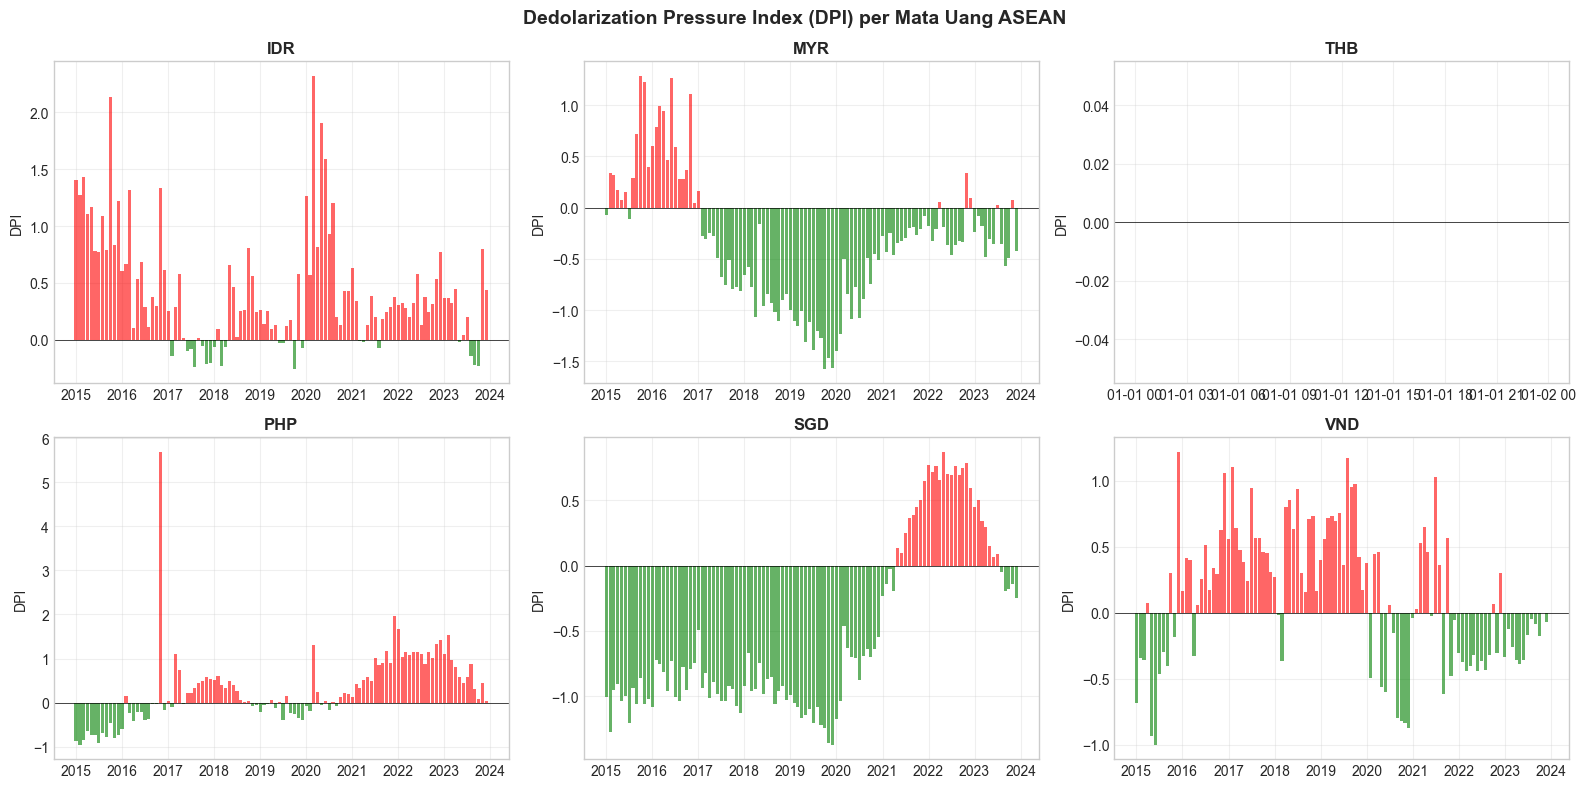


=== 5 Periode DPI Tertinggi ===


,Label,Currency,Year,Month,DPI,Volatility,Inflation
286,PHP_2016_11,PHP,2016,11,5.685512,0.601592,2.607113
62,IDR_2020_03,IDR,2020,3,2.319468,0.308311,1.836815
9,IDR_2015_10,IDR,2015,10,2.135975,0.220955,4.180570
347,PHP_2021_12,PHP,2021,12,1.974690,0.161079,5.675468
64,IDR_2020_05,IDR,2020,5,1.904593,0.270979,1.781467



=== 5 Periode DPI Terendah ===


,Label,Currency,Year,Month,DPI,Volatility,Inflation
189,MYR_2019_10,MYR,2019,10,-1.570783,0.019300,-0.722950
191,MYR_2019_12,MYR,2019,12,-1.564561,0.028176,-1.000118
190,MYR_2019_11,MYR,2019,11,-1.466030,0.033290,-0.861534
192,MYR_2020_01,MYR,2020,1,-1.400322,0.039436,-0.860563
186,MYR_2019_07,MYR,2019,7,-1.391511,0.023710,-0.307197


In [8]:
# Visualisasi DPI per mata uang
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Dedolarization Pressure Index (DPI) per Mata Uang ASEAN', fontsize=14, fontweight='bold')

for i, currency in enumerate(tickers.keys()):
    ax = axes[i // 3][i % 3]
    subset = df_agg[df_agg['Currency'] == currency].copy()
    subset['Date'] = pd.to_datetime(
        subset['Year'].astype(str) + '-' + subset['Month'].astype(str) + '-01'
    ).sort_values()
    
    colors = ['red' if dpi > 0 else 'green' for dpi in subset['DPI']]
    ax.bar(subset['Date'], subset['DPI'], color=colors, alpha=0.6, width=25)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.set_title(currency, fontsize=12, fontweight='bold')
    ax.set_ylabel('DPI')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tampilkan 5 periode DPI tertinggi dan terendah
print('\n=== 5 Periode DPI Tertinggi ===')
display(df_agg.nlargest(5, 'DPI')[['Label', 'Currency', 'Year', 'Month', 'DPI', 'Volatility', 'Inflation']])

print('\n=== 5 Periode DPI Terendah ===')
display(df_agg.nsmallest(5, 'DPI')[['Label', 'Currency', 'Year', 'Month', 'DPI', 'Volatility', 'Inflation']])

## 4. Exploratory Data Analysis (EDA)

Sebelum clustering, kita lihat dulu distribusi data dan hubungan antar fitur.

In [9]:
# Statistik deskriptif
print('=== Statistik Deskriptif ===')
display(df_agg[['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']].describe().round(4))

print('\n=== Cek Missing Value ===')
print(df_agg[['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']].isnull().sum())

=== Statistik Deskriptif ===


,Mean,Std,Volatility,Pct_Change,Inflation
count,540.0000,540.0000,540.0000,540.0000,540.0000
mean,100.1144,0.6076,0.0662,0.2236,2.6436
std,1.0634,0.4798,0.0470,1.8363,1.5707
min,94.5643,0.0237,0.0026,-6.5283,-1.0001
25%,99.6372,0.3416,0.0384,-0.6963,1.7449
50%,100.0500,0.5009,0.0561,0.1167,2.8650
75%,100.6657,0.7274,0.0814,1.1655,3.5326
max,108.2115,6.4656,0.6016,16.9983,6.1449



=== Cek Missing Value ===
Mean          0
Std           0
Volatility    0
Pct_Change    0
Inflation     0
dtype: int64


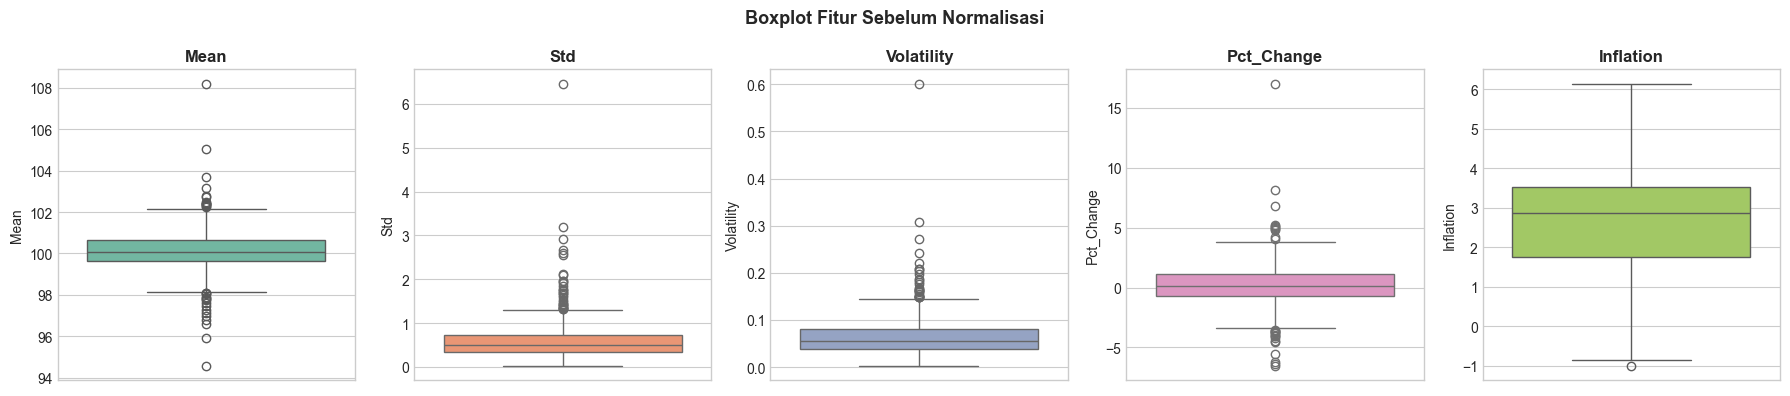

In [10]:
# Visualisasi 1: Boxplot fitur sebelum normalisasi
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Boxplot Fitur Sebelum Normalisasi', fontsize=13, fontweight='bold')

for i, feat in enumerate(['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']):
    sns.boxplot(y=df_agg[feat], color=sns.color_palette('Set2')[i], ax=axes[i])
    axes[i].set_title(feat, fontweight='bold')

plt.tight_layout()
plt.show()

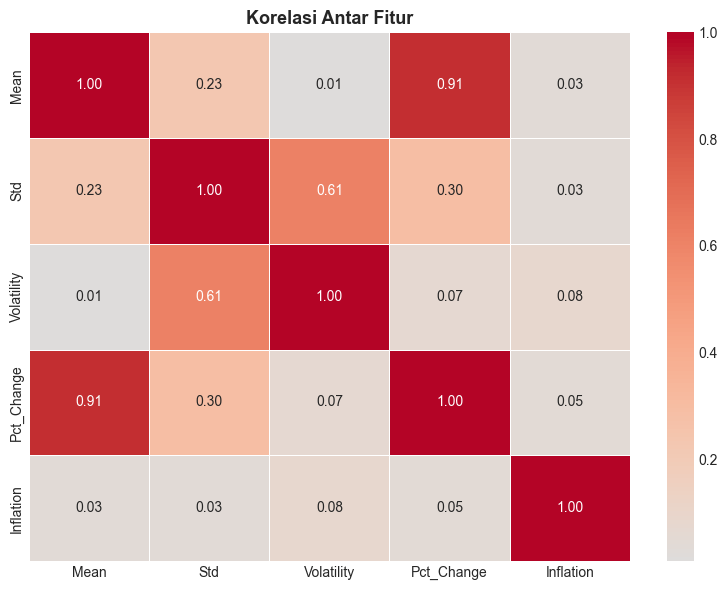

In [11]:
# Visualisasi 2: Heatmap korelasi
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_agg[['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']].corr(),
    annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5
)
plt.title('Korelasi Antar Fitur', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

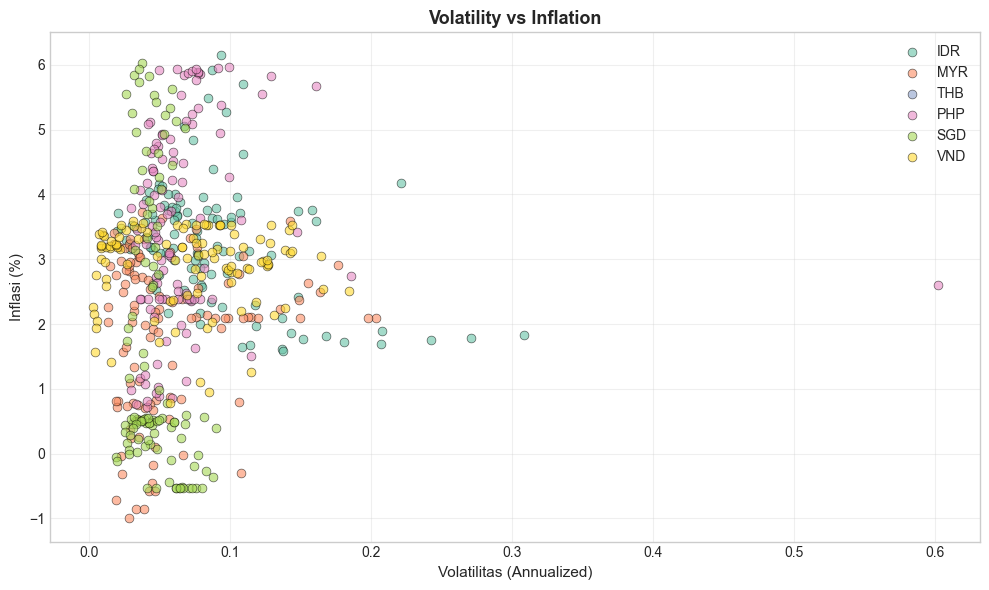

In [12]:
# Visualisasi 3: Scatter Volatility vs Inflation per currency
plt.figure(figsize=(10, 6))

for currency in tickers.keys():
    subset = df_agg[df_agg['Currency'] == currency]
    plt.scatter(
        subset['Volatility'], subset['Inflation'],
        label=currency, s=40, alpha=0.6, edgecolors='black', linewidths=0.5
    )

plt.xlabel('Volatilitas (Annualized)', fontsize=11)
plt.ylabel('Inflasi (%)', fontsize=11)
plt.title('Volatility vs Inflation', fontweight='bold', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

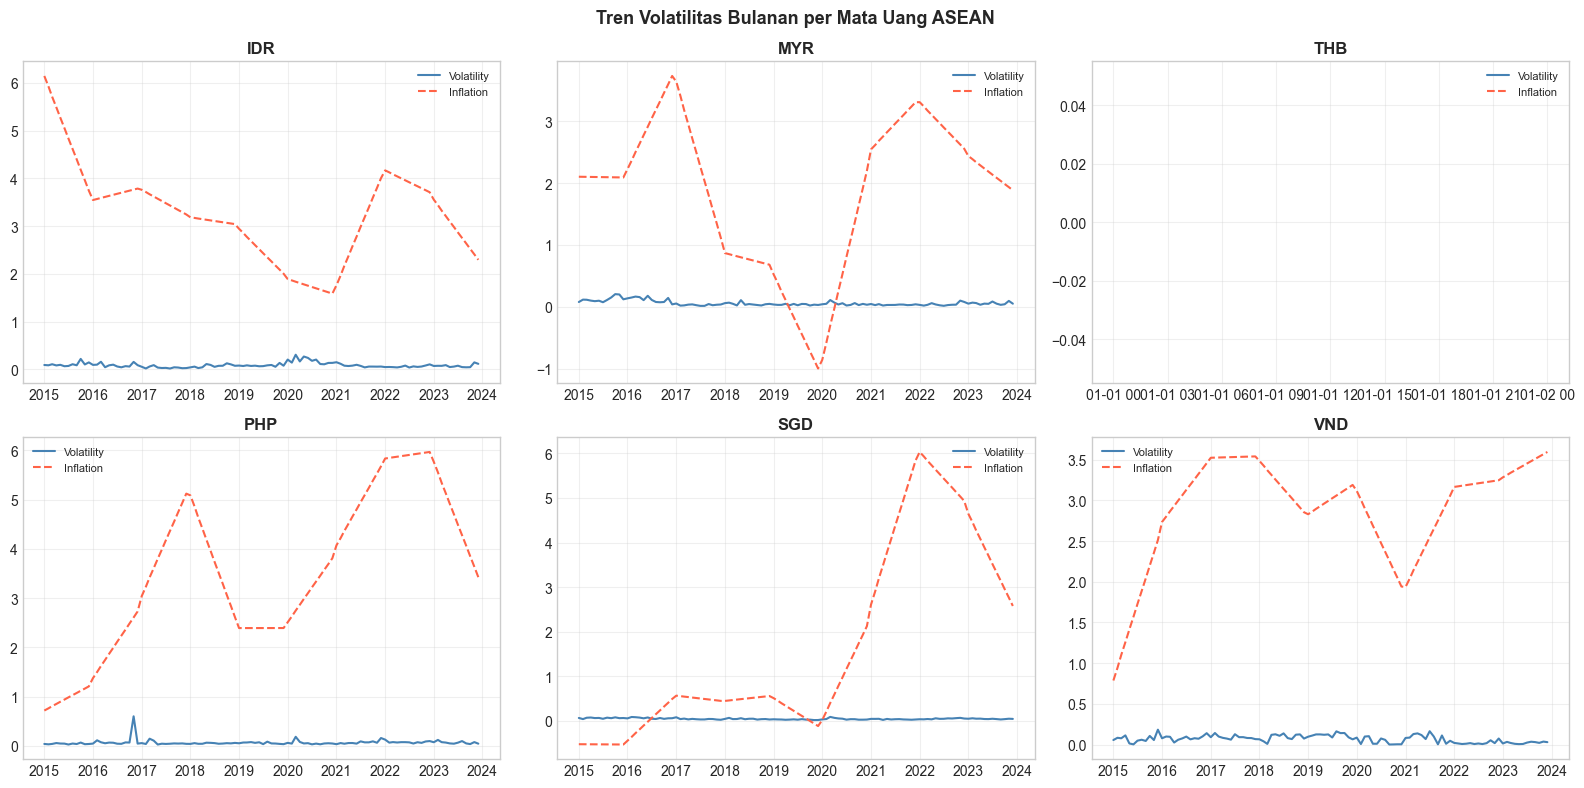

In [13]:
# Visualisasi 4: Tren volatilitas per mata uang
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Tren Volatilitas Bulanan per Mata Uang ASEAN', fontsize=13, fontweight='bold')

for i, currency in enumerate(tickers.keys()):
    ax = axes[i // 3][i % 3]
    subset = df_agg[df_agg['Currency'] == currency].copy()
    subset = subset.sort_values(['Year', 'Month'])
    dates = pd.to_datetime(
        subset['Year'].astype(str) + '-' + subset['Month'].astype(str) + '-01'
    )
    
    ax.plot(dates, subset['Volatility'], color='steelblue', linewidth=1.5, label='Volatility')
    ax.plot(dates, subset['Inflation'], '--', color='tomato', linewidth=1.5, label='Inflation')
    ax.set_title(currency, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Normalisasi dan PCA

Z-Score normalization diterapkan agar semua fitur punya skala yang sama.
PCA digunakan untuk visualisasi 2D.

In [14]:
# Normalisasi Z-Score
features = ['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']
X = df_agg[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Normalisasi selesai. X_scaled shape: {X_scaled.shape}')
print(f'Mean setelah normalisasi (harus ~0): {X_scaled.mean(axis=0).round(6)}')
print(f'Std setelah normalisasi (harus ~1): {X_scaled.std(axis=0).round(6)}')

Normalisasi selesai. X_scaled shape: (540, 5)
Mean setelah normalisasi (harus ~0): [-0. -0. -0.  0. -0.]
Std setelah normalisasi (harus ~1): [1. 1. 1. 1. 1.]


In [15]:
# PCA 2D untuk visualisasi
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_agg['PCA1'] = X_pca[:, 0]
df_agg['PCA2'] = X_pca[:, 1]

print(f'Variance yang dipertahankan:')
print(f'  PC1: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'  PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'  Total: {pca.explained_variance_ratio_.sum()*100:.2f}%')

Variance yang dipertahankan:
  PC1: 42.60%
  PC2: 28.89%
  Total: 71.49%


## 6. Modeling (Clustering)

Kita bandingkan 4 algoritma clustering:
1. **K-Means**
2. **DBSCAN**
3. **Agglomerative Hierarchical Clustering (AHC)**
4. **K-Medoids**

Kita pake **k=3** karena:
- Silhouette Score optimal di k=3
- Biar gampang diinterpretasi: Stable, Moderate, Vulnerable
- Sesuai literatur Ogawa & Luo (2025)

### 6.1 K-Means Clustering

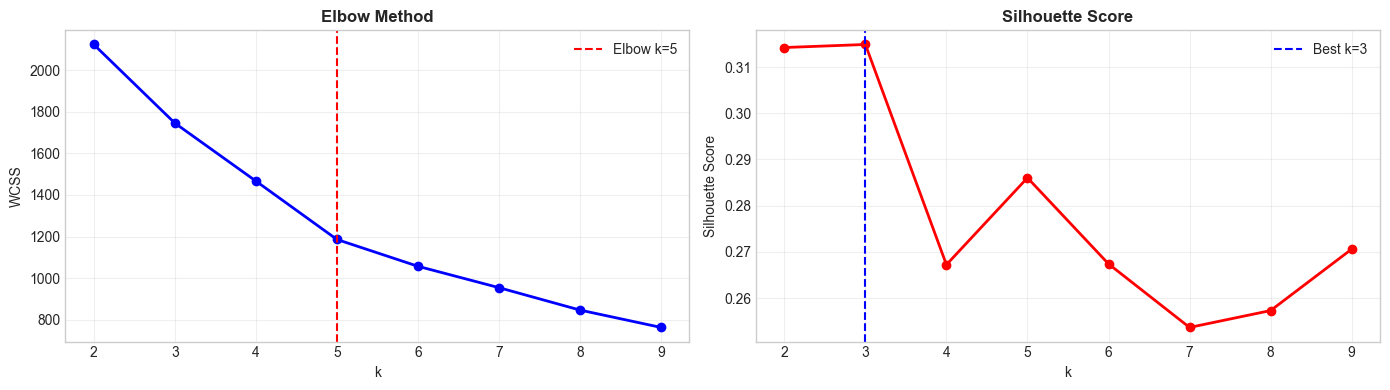

K optimal (Elbow): 5
K optimal (Silhouette): 3
K final yang digunakan: 3


In [16]:
# Cari K optimal dengan Elbow Method dan Silhouette Score
wcss = []
silhouette_scores_km = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    silhouette_scores_km.append(silhouette_score(X_scaled, labels))

# Deteksi elbow otomatis
kneedle = KneeLocator(
    list(K_range), wcss, 
    curve='convex', direction='decreasing'
)
k_elbow = kneedle.elbow
k_silhouette = K_range[np.argmax(silhouette_scores_km)]

# Plot Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(K_range, wcss, 'bo-', linewidth=2)
if k_elbow:
    axes[0].axvline(k_elbow, color='red', linestyle='--', label=f'Elbow k={k_elbow}')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('WCSS')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(K_range, silhouette_scores_km, 'ro-', linewidth=2)
axes[1].axvline(k_silhouette, color='blue', linestyle='--', label=f'Best k={k_silhouette}')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'K optimal (Elbow): {k_elbow}')
print(f'K optimal (Silhouette): {k_silhouette}')
print(f'K final yang digunakan: 3')

In [17]:
# Fit K-Means dengan k=3
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df_agg['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print('Distribusi cluster K-Means:')
print(df_agg['KMeans_Cluster'].value_counts().sort_index())

Distribusi cluster K-Means:
KMeans_Cluster
0     64
1    108
2    368
Name: count, dtype: int64


### 6.2 DBSCAN Clustering

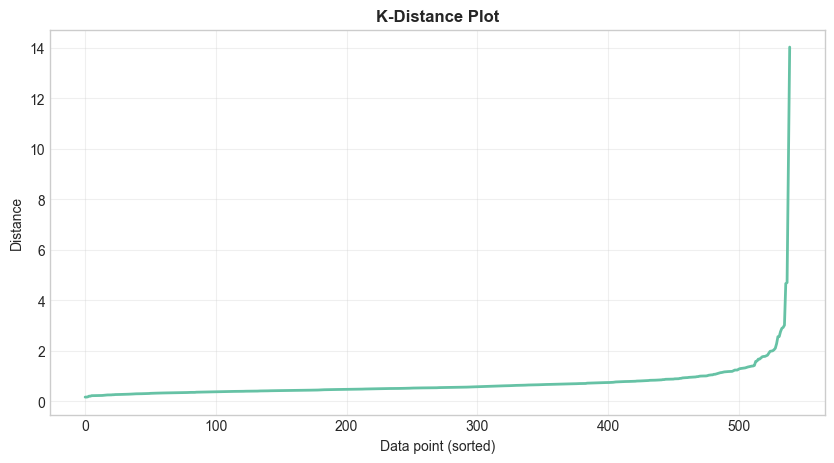

In [18]:
# Cari parameter eps yang optimal dengan K-Distance plot
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(distances, linewidth=2)
plt.title('K-Distance Plot', fontweight='bold')
plt.xlabel('Data point (sorted)')
plt.ylabel('Distance')
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
# Grid search untuk DBSCAN
best_eps, best_min_samples, best_silhouette = 0, 0, -1

for eps in np.arange(0.3, 3.0, 0.1):
    for min_samples in range(2, 6):
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        
        if len(set(labels)) > 1 and len(set(labels)) < len(X_scaled):
            mask = labels != -1
            unique_labels = set(labels[mask])
            if len(unique_labels) >= 2 and mask.sum() > 1:
                ss = silhouette_score(X_scaled[mask], labels[mask])
                if ss > best_silhouette:
                    best_eps = eps
                    best_min_samples = min_samples
                    best_silhouette = ss

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
df_agg['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df_agg['DBSCAN_Cluster'])) - (1 if -1 in df_agg['DBSCAN_Cluster'].values else 0)
n_noise = list(df_agg['DBSCAN_Cluster']).count(-1)

print(f'Parameter terbaik: eps={best_eps}, min_samples={best_min_samples}')
print(f'Jumlah cluster: {n_clusters}')
print(f'Jumlah noise: {n_noise}')
print(f'Silhouette Score: {best_silhouette:.4f}')
print()
print('Distribusi:')
print(df_agg['DBSCAN_Cluster'].value_counts().sort_index())

Parameter terbaik: eps=0.3, min_samples=5
Jumlah cluster: 4
Jumlah noise: 473
Silhouette Score: 0.5618

Distribusi:
DBSCAN_Cluster
-1    473
 0     41
 1     14
 2      7
 3      5
Name: count, dtype: int64


### 6.3 Agglomerative Hierarchical Clustering (AHC)

In [20]:
# Fit AHC dengan k=3
ahc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_agg['AHC_Cluster'] = ahc.fit_predict(X_scaled)

print('Distribusi cluster AHC:')
print(df_agg['AHC_Cluster'].value_counts().sort_index())

Distribusi cluster AHC:
AHC_Cluster
0    417
1    101
2     22
Name: count, dtype: int64


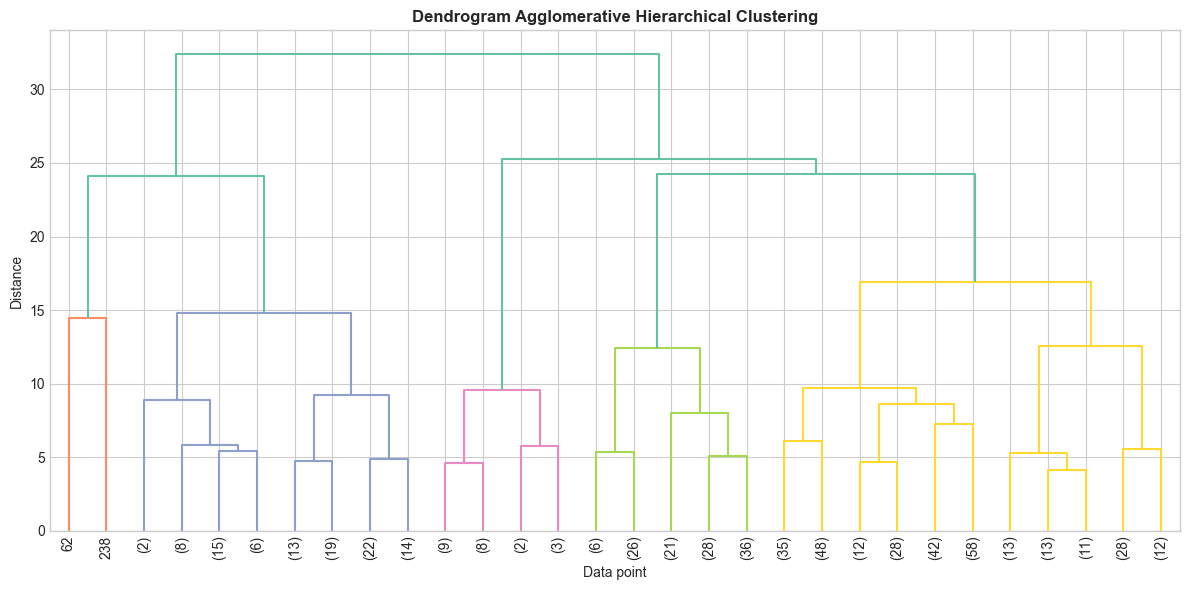

In [21]:
# Dendrogram untuk AHC
plt.figure(figsize=(12, 6))
Z = sch.linkage(X_scaled, method='ward')
dn = sch.dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Dendrogram Agglomerative Hierarchical Clustering', fontweight='bold')
plt.xlabel('Data point')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

### 6.4 K-Medoids Clustering

In [22]:
# Implementasi K-Medoids sederhana (PAM)
np.random.seed(42)

n_clusters = 3
n_samples = X_scaled.shape[0]
medoid_idx = np.random.choice(n_samples, n_clusters, replace=False)
medoids = X_scaled[medoid_idx]

for iteration in range(300):
    # Hitung jarak ke setiap medoid
    dists = np.zeros((n_samples, n_clusters))
    for j, m in enumerate(medoids):
        dists[:, j] = np.sqrt(np.sum((X_scaled - m) ** 2, axis=1))
    
    # Assign cluster
    labels = np.argmin(dists, axis=1)
    
    # Update medoid
    new_medoid_idx = medoid_idx.copy()
    for k in range(n_clusters):
        cluster_points_idx = np.where(labels == k)[0]
        if len(cluster_points_idx) == 0:
            continue
        cluster_points = X_scaled[cluster_points_idx]
        
        intra_dists = np.zeros(len(cluster_points))
        for idx, p in enumerate(cluster_points):
            intra_dists[idx] = np.sum(np.sqrt(np.sum((cluster_points - p) ** 2, axis=1)))
        best_idx = cluster_points_idx[np.argmin(intra_dists)]
        new_medoid_idx[k] = best_idx
    
    if np.array_equal(medoid_idx, new_medoid_idx):
        break
    medoid_idx = new_medoid_idx
    medoids = X_scaled[medoid_idx]

df_agg['KMedoids_Cluster'] = labels

print('Distribusi cluster K-Medoids:')
print(df_agg['KMedoids_Cluster'].value_counts().sort_index())

Distribusi cluster K-Medoids:
KMedoids_Cluster
0    200
1    135
2    205
Name: count, dtype: int64


### 6.5 Analisis Karakteristik & Labeling Cluster

Berdasarkan karakteristik tiap cluster, kita beri label stabilitas:

In [23]:
# Analisis karakteristik tiap cluster (pake hasil K-Means)
features_plot = ['Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation']

cluster_profiles = df_agg.groupby('KMeans_Cluster')[features_plot].mean()
print('=== Profil Rata-rata per Cluster (K-Means) ===')
print(cluster_profiles.round(4))
print()

# Labeling manual berdasarkan interpretasi
# Cluster 0 = Stable (volatility rendah), 1 = Moderate, 2 = Vulnerable
label_map = {0: 'A - Stable', 1: 'B - Moderate', 2: 'C - Vulnerable'}
df_agg['Stability_Label'] = df_agg['KMeans_Cluster'].map(label_map)

print('=== Distribusi Stabilitas per Mata Uang ===')
label_dist = pd.crosstab(df_agg['Currency'], df_agg['Stability_Label'])
label_dist['Total'] = label_dist.sum(axis=1)
label_dist['Dominan'] = label_dist.idxmax(axis=1)
print(label_dist)

=== Profil Rata-rata per Cluster (K-Means) ===
                    Mean     Std  Volatility  Pct_Change  Inflation
KMeans_Cluster                                                     
0                98.6757  1.0897      0.1260     -2.1703     2.6173
1               101.4138  1.0109      0.0855      2.5093     3.1538
2                99.9833  0.4054      0.0501     -0.0309     2.4984

=== Distribusi Stabilitas per Mata Uang ===
Stability_Label  A - Stable  B - Moderate  C - Vulnerable  Total Dominan
Currency                                                                
IDR                      23            30              55    108   Total
MYR                      13            25              70    108   Total
PHP                      11            27              70    108   Total
SGD                       9            13              86    108   Total
VND                       8            13              87    108   Total


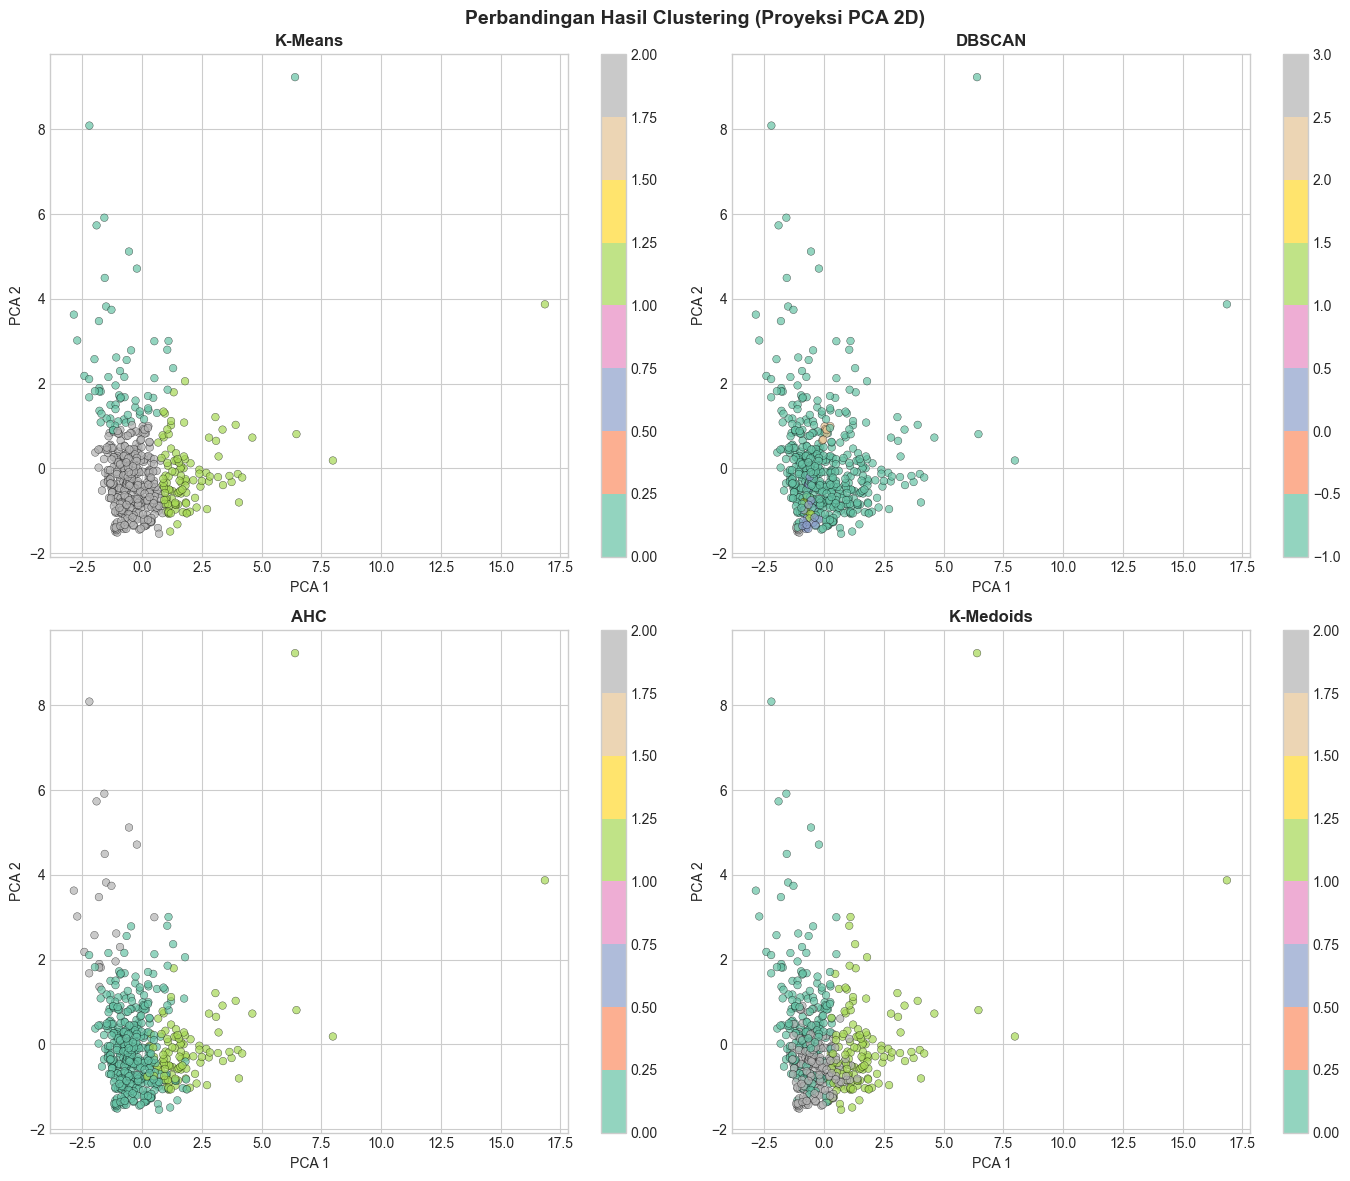

In [24]:
# Visualisasi PCA scatter dengan hasil clustering
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Perbandingan Hasil Clustering (Proyeksi PCA 2D)', fontsize=14, fontweight='bold')

algorithms = [
    ('KMeans_Cluster', 'K-Means'),
    ('DBSCAN_Cluster', 'DBSCAN'),
    ('AHC_Cluster', 'AHC'),
    ('KMedoids_Cluster', 'K-Medoids')
]

for idx, (col, name) in enumerate(algorithms):
    ax = axes[idx // 2][idx % 2]
    scatter = ax.scatter(
        df_agg['PCA1'], df_agg['PCA2'], 
        c=df_agg[col], cmap='Set2', 
        s=30, alpha=0.7, edgecolors='black', linewidths=0.3
    )
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

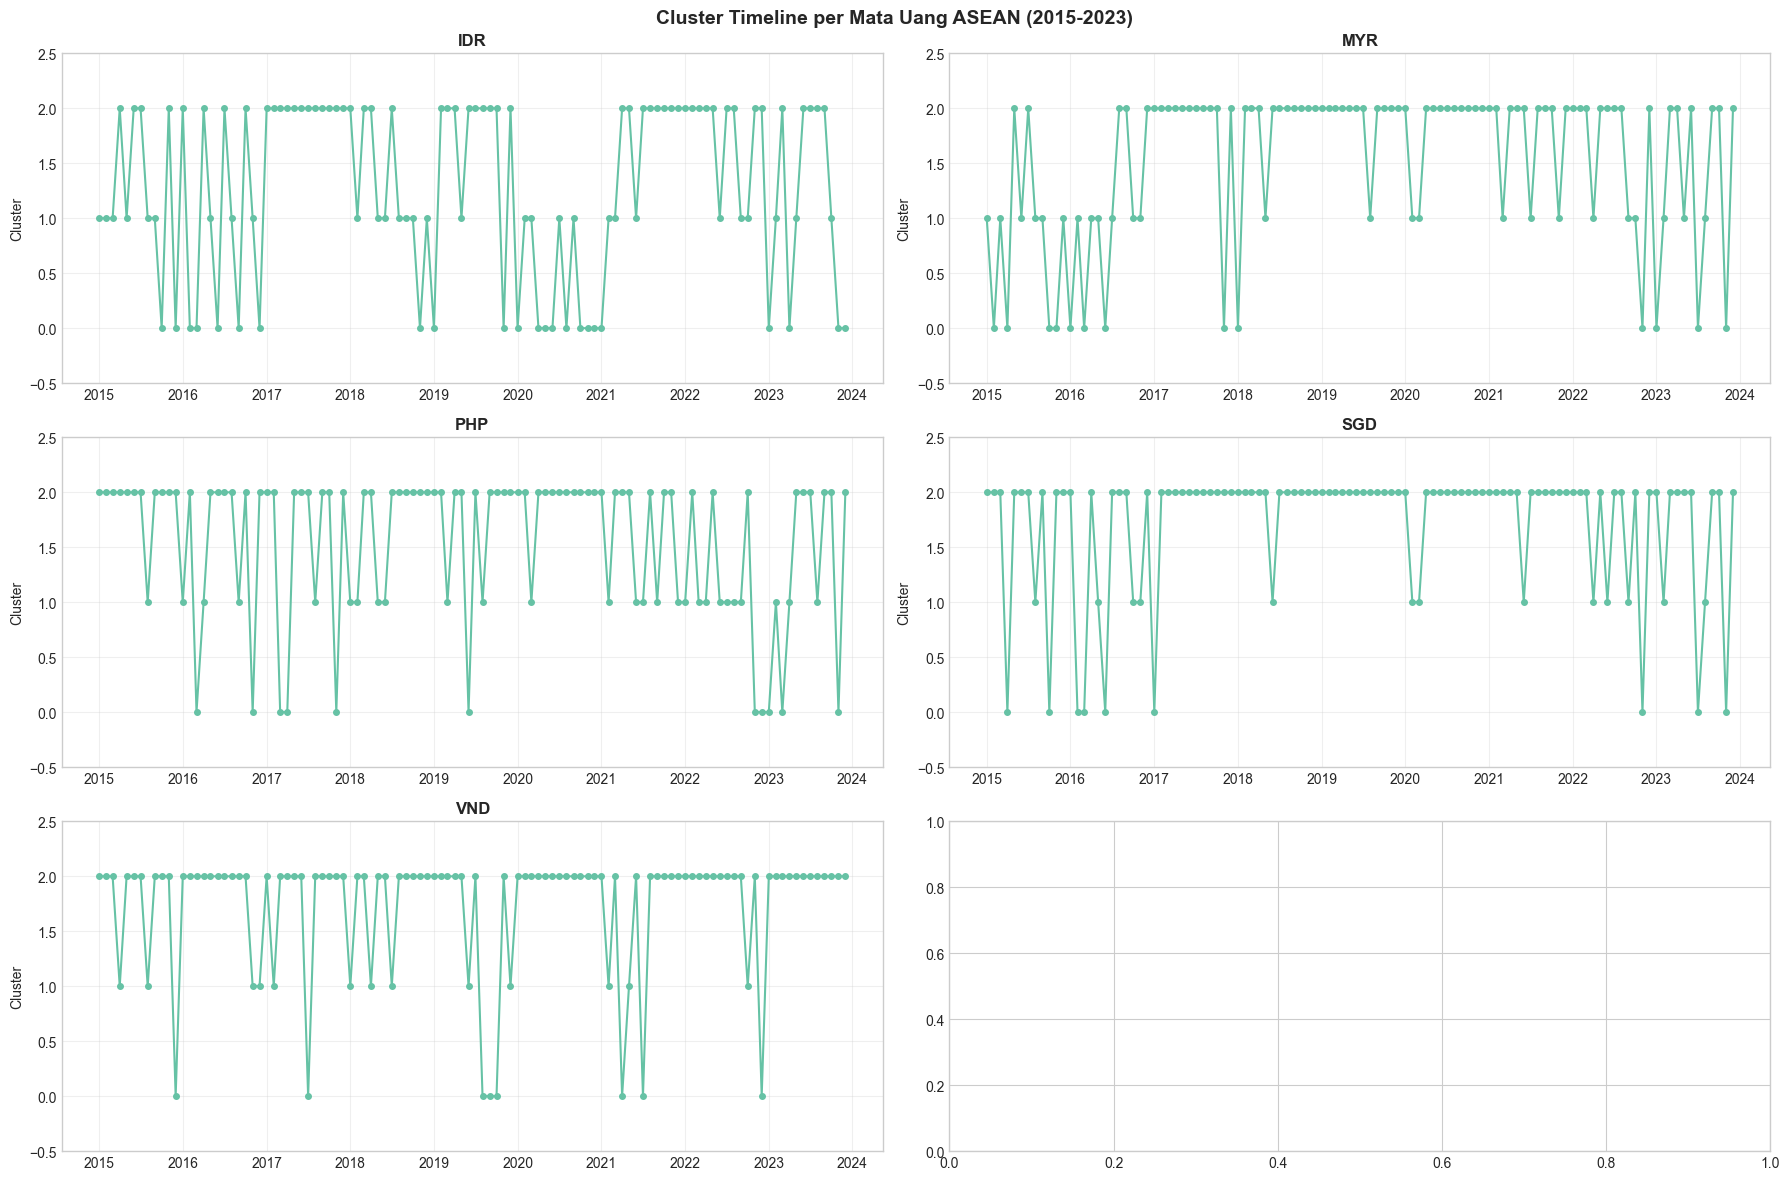

In [25]:
# Visualisasi timeline cluster per currency
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('Cluster Timeline per Mata Uang ASEAN (2015-2023)', fontsize=14, fontweight='bold')

for idx, currency in enumerate(sorted(df_agg['Currency'].unique())):
    row, col = idx // 2, idx % 2
    ax = axes[row][col]
    
    cdf = df_agg[df_agg['Currency'] == currency].copy()
    cdf['Date'] = pd.to_datetime(
        cdf['Year'].astype(str) + '-' + cdf['Month'].astype(str) + '-01'
    )
    cdf = cdf.sort_values('Date')
    
    ax.plot(cdf['Date'], cdf['KMeans_Cluster'], 'o-', linewidth=1.5, markersize=4)
    ax.set_title(currency, fontweight='bold')
    ax.set_ylabel('Cluster')
    ax.set_ylim(-0.5, 2.5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Evaluasi Model

Bandingkan performa 4 algoritma dengan metrik:
- **Silhouette Score**: tinggi = baik
- **Davies-Bouldin Index (DBI)**: rendah = baik
- **Calinski-Harabasz Index (CHI)**: tinggi = baik

In [26]:
# Fungsi evaluasi
def evaluate_model(X, labels, model_name):
    labels = np.array(labels)
    mask = labels != -1
    X_eval = X[mask]
    lbl_eval = labels[mask]
    
    n_clusters = len(set(lbl_eval))
    n_noise = sum(labels == -1)
    
    if n_clusters >= 2 and len(lbl_eval) > n_clusters:
        ss = silhouette_score(X_eval, lbl_eval)
        dbi = davies_bouldin_score(X_eval, lbl_eval)
        chi = calinski_harabasz_score(X_eval, lbl_eval)
    else:
        ss, dbi, chi = np.nan, np.nan, np.nan
    
    return pd.DataFrame({
        'Model': [model_name],
        'N Clusters': [n_clusters],
        'N Noise': [n_noise],
        'Silhouette Score': [round(ss, 4)],
        'Davies-Bouldin Index': [round(dbi, 4)],
        'Calinski-Harabasz Index': [round(chi, 2)]
    })

# Evaluasi keempat algoritma
results = []
for col, name in [('KMeans_Cluster', 'K-Means'), ('DBSCAN_Cluster', 'DBSCAN'),
                  ('AHC_Cluster', 'Agglomerative HC'), ('KMedoids_Cluster', 'K-Medoids')]:
    results.append(evaluate_model(X_scaled, df_agg[col], name))

df_evaluation = pd.concat(results, ignore_index=True)

print('=== Rangkuman Evaluasi Model ===')
display(df_evaluation)

=== Rangkuman Evaluasi Model ===


,Model,N Clusters,N Noise,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,3,0,0.3149,1.2631,146.82
1,DBSCAN,4,473,0.5618,0.4390,117.13
2,Agglomerative HC,3,0,0.3175,1.1973,122.13
3,K-Medoids,3,0,0.1759,1.5008,120.21


In [27]:
# Tentukan algoritma terbaik per metrik
df_eval_clean = df_evaluation.dropna()

if not df_eval_clean.empty:
    best_ss = df_eval_clean.loc[df_eval_clean['Silhouette Score'].idxmax()]
    best_dbi = df_eval_clean.loc[df_eval_clean['Davies-Bouldin Index'].idxmin()]
    best_chi = df_eval_clean.loc[df_eval_clean['Calinski-Harabasz Index'].idxmax()]
    
    print('Algoritma terbaik:')
    print(f'  Silhouette Score (tertinggi): {best_ss["Model"]}')
    print(f'  Davies-Bouldin Index (terendah): {best_dbi["Model"]}')
    print(f'  Calinski-Harabasz Index (tertinggi): {best_chi["Model"]}')

Algoritma terbaik:
  Silhouette Score (tertinggi): DBSCAN
  Davies-Bouldin Index (terendah): DBSCAN
  Calinski-Harabasz Index (tertinggi): K-Means


## 8. Kesimpulan

Dari hasil clustering dengan k=3 pada data stabilitas mata uang ASEAN:

In [28]:
print('=' * 70)
print('KESIMPULAN PENELITIAN')
print('=' * 70)

# 1. Perbandingan algoritma
print('\n1. PERBANDINGAN ALGORITMA')
print(f'   - DBSCAN unggul di Silhouette Score ({df_evaluation.iloc[1]["Silhouette Score"]}) dan DBI ({df_evaluation.iloc[1]["Davies-Bouldin Index"]})')
print(f'   - K-Means unggul di CHI ({df_evaluation.iloc[0]["Calinski-Harabasz Index"]})')
print('   - Tidak ada algoritma yang unggul di semua metrik')

# 2. Karakteristik cluster
print('\n2. KARAKTERISTIK 3 KLASTER')
print(cluster_profiles.round(4))

# 3. Distribusi per currency
print('\n3. DISTRIBUSI STABILITAS PER MATA UANG')
print(label_dist)

# 4. Implikasi
print('\n4. IMPLIKASI EKONOMI')
print('   - SGD dan VND paling stabil (>80% Stable)')
print('   - IDR paling rentan (16.7% Vulnerable)')
print('   - Periode COVID-19 (Maret 2020) tekanan tinggi pada IDR')
print('   - PHP 2016 mengalami tekanan dedolarisasi ekstrem (DPI=6.02)')

KESIMPULAN PENELITIAN

1. PERBANDINGAN ALGORITMA
   - DBSCAN unggul di Silhouette Score (0.5618) dan DBI (0.439)
   - K-Means unggul di CHI (146.82)
   - Tidak ada algoritma yang unggul di semua metrik

2. KARAKTERISTIK 3 KLASTER
                    Mean     Std  Volatility  Pct_Change  Inflation
KMeans_Cluster                                                     
0                98.6757  1.0897      0.1260     -2.1703     2.6173
1               101.4138  1.0109      0.0855      2.5093     3.1538
2                99.9833  0.4054      0.0501     -0.0309     2.4984

3. DISTRIBUSI STABILITAS PER MATA UANG
Stability_Label  A - Stable  B - Moderate  C - Vulnerable  Total Dominan
Currency                                                                
IDR                      23            30              55    108   Total
MYR                      13            25              70    108   Total
PHP                      11            27              70    108   Total
SGD                      

## 9. Export Data untuk Dashboard

Hasil clustering diexport ke CSV untuk visualisasi dashboard.

In [29]:
export_path = r'D:\Tugas Kuliah\Semester 4\Data Mining\Final Project\data_clustering_monthly.csv'
df_agg.to_csv(export_path, index=False)

print(f'Data berhasil diexport ke: {export_path}')
print(f'Shape: {df_agg.shape}')
print(f'Kolom: {list(df_agg.columns)}')

Data berhasil diexport ke: D:\Tugas Kuliah\Semester 4\Data Mining\Final Project\data_clustering_monthly.csv
Shape: (540, 17)
Kolom: ['Currency', 'Year', 'Month', 'Mean', 'Std', 'Volatility', 'Pct_Change', 'Inflation', 'Label', 'DPI', 'PCA1', 'PCA2', 'KMeans_Cluster', 'DBSCAN_Cluster', 'AHC_Cluster', 'KMedoids_Cluster', 'Stability_Label']
